# **💳 BNPL Credit Risk & Default Prediction**
## **Complete EDA + Feature Engineering + XGBoost Model**

---


> **Dataset:** BNPL Credit Risk & Default Prediction  
> **Goal:** Understand who defaults on BNPL payments — and build a model to predict it

---

### **📌 What is BNPL?**
Buy Now, Pay Later (BNPL) lets customers purchase products immediately and pay in small installments over time — think of it like a mini loan at the checkout counter. Companies like Klarna, Afterpay, and Razorpay offer this service. The big challenge? **Predicting who will default** before giving them credit.

### **🗺️ Notebook Road Map**
| Step | What We Do |
|---|---|
| 1 | Import libraries & load data |
| 2 | Quick data health check |
| 3 | Exploratory Data Analysis (EDA) |
| 4 | Feature Engineering |
| 5 | Build XGBoost Model |
| 6 | Evaluate & Interpret Results |
| 7 | Key Takeaways |

In [ ]:
### **Version naturelle pour un entretien**

**One of the projects I’m currently working on is a BNPL credit risk and default prediction project.**

BNPL stands for **Buy Now, Pay Later**. It allows customers to purchase a product immediately and pay for it later through several installments. From a business perspective, the main risk is that some customers may fail to repay what they owe.

**The objective of my project is to identify the factors associated with default and build a machine learning model that can predict the probability of default for each customer.**

I started with **exploratory data analysis** to understand the customer population and compare the characteristics of customers who default with those who successfully repay their installments.

Then, I worked on **feature engineering**, using information such as customer characteristics, financial behavior, purchase information, and repayment history to create more relevant features for the model.

For the modeling part, I’m currently using **XGBoost for binary classification**, where the target is whether the customer defaults or not.

I’m also paying particular attention to **class imbalance and model evaluation**. In credit risk, accuracy alone can be misleading, so I look at metrics such as **precision, recall, F1-score, ROC-AUC, and the confusion matrix**.

Finally, the goal is not only to obtain a good predictive model, but also to **understand why the model considers a customer risky**. That’s why I use feature importance and explainability techniques such as **SHAP**.

**From a business perspective, the model could help a BNPL provider make better credit decisions, reduce default risk, and identify high-risk customers before granting credit.**

Precision  Recall  F1 score     MCC  ROC-AUC
Model    Dataset                                                 
CatBoost Test           0.5642  0.5000    0.5302  0.2592   0.7095
         Validation     0.5662  0.4698    0.5135  0.2489   0.7208
LightGBM Test           0.5698  0.5050    0.5354  0.2676   0.6984
         Validation     0.5392  0.4341    0.4810  0.2059   0.7070
XGBoost  Test           0.5026  0.4802    0.4911  0.1775   0.6756
         Validation     0.5122  0.4615    0.4855  0.1832   0.6821

,Precision,Recall,F1 score,MCC,ROC-AUC
Model,,,,,
CatBoost,0.566200,0.469800,0.513500,0.248900,0.720800
LightGBM,0.539200,0.434100,0.481000,0.205900,0.707000
XGBoost,0.512200,0.461500,0.485500,0.183200,0.682100


Candidate selected from validation metrics: CatBoost


---
## **📦 Step 1 — Import Libraries & Load Data**
We keep imports clean and grouped — data handling, visualization, and ML separately.

In [1]:
# ── Data Handling ──────────────────────────────────────────
import warnings

import numpy as np
import pandas as pd

warnings.filterwarnings('ignore')

# ── Visualization ──────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)

# ── Machine Learning ───────────────────────────────────────
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from xgboost import XGBClassifier

# ── Style ──────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})

COLORS = {'default': '#E24B4A', 'paid': '#1D9E75',
          'main': '#378ADD', 'accent': '#BA7517'}

# ── Load Data ──────────────────────────────────────────────
df = pd.read_csv('/kaggle/input/datasets/shree0910/buy-now-and-pay-later-fintech-ml-dataset/Buy_Now_Pay_Later_BNPL_CreditRisk_Dataset.csv')
df['transaction_date'] = pd.to_datetime(df['transaction_date'])

print(f'✅ Dataset loaded — {df.shape[0]:,} rows × {df.shape[1]} columns')
df.head()

✅ Dataset loaded — 10,345 rows × 17 columns


,user_id,age,employment_type,monthly_income,credit_score,purchase_amount,product_category,bnpl_installments,repayment_delay_days,missed_payments,default_flag,app_usage_frequency,location,transaction_date,debt_to_income_ratio,risk_score,customer_segment
0,1,56,Salaried,68529.50,552,5000.00,Electronics,12,13,1,0,8.49,Australia,2023-06-10,0.072961,165.2,Medium Risk
1,2,19,Student,7247.85,300,1073.23,Fashion,12,13,1,0,3.09,USA,2024-10-07,0.148076,266.0,High Risk
2,3,20,Self-Employed,41582.26,471,5000.00,Electronics,3,19,2,0,3.33,Australia,2023-04-05,0.120244,229.6,High Risk
3,4,21,Salaried,14423.46,300,4076.83,Sports,6,18,5,1,5.86,Germany,2023-06-24,0.282653,356.0,High Risk
4,5,43,Salaried,42845.50,512,5000.00,Electronics,9,0,0,0,7.36,India,2024-10-19,0.116698,135.2,High Risk


---
## **🩺 Step 2 — Data Health Check**
Before doing anything fancy, we always check the basics:
- How many rows and columns?
- Any missing values?
- Are the data types correct?
- Is the target variable balanced?

In [2]:
print('=' * 50)
print(f'  Shape     : {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'  Duplicates: {df.duplicated().sum()}')
print(f'  Missing   : {df.isnull().sum().sum()} total null values')
print('=' * 50)
df.info()

  Shape     : 10,345 rows × 17 columns
  Duplicates: 0
  Missing   : 0 total null values
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10345 entries, 0 to 10344
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   user_id               10345 non-null  int64         
 1   age                   10345 non-null  int64         
 2   employment_type       10345 non-null  object        
 3   monthly_income        10345 non-null  float64       
 4   credit_score          10345 non-null  int64         
 5   purchase_amount       10345 non-null  float64       
 6   product_category      10345 non-null  object        
 7   bnpl_installments     10345 non-null  int64         
 8   repayment_delay_days  10345 non-null  int64         
 9   missed_payments       10345 non-null  int64         
 10  default_flag          10345 non-null  int64         
 11  app_usage_frequency   10345 non-null  float

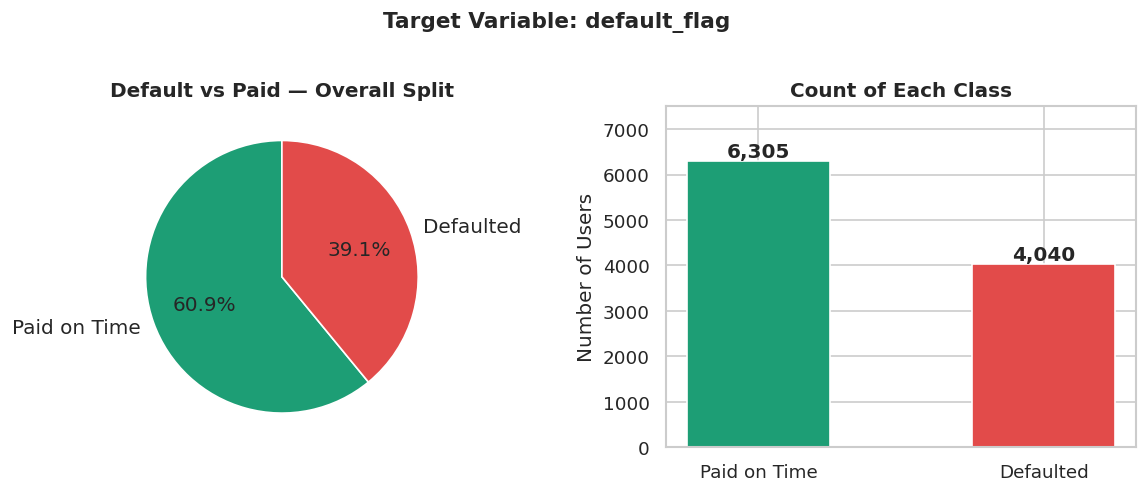


📊 Default Rate: 39.1%  |  Paid Rate: 60.9%
💡 Mild class imbalance — XGBoost handles this well with scale_pos_weight


In [3]:
# Target variable distribution
counts = df['default_flag'].value_counts()
labels = ['Paid on Time', 'Defaulted']
colors = [COLORS['paid'], COLORS['default']]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Pie chart
axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[0].set_title('Default vs Paid — Overall Split', fontweight='bold')

# Bar chart
bars = axes[1].bar(labels, counts.values, color=colors, width=0.5, edgecolor='white')
for bar, val in zip(bars, counts.values, strict=False):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}', ha='center', fontweight='bold', fontsize=12)
axes[1].set_title('Count of Each Class', fontweight='bold')
axes[1].set_ylabel('Number of Users')
axes[1].set_ylim(0, 7500)

plt.suptitle('Target Variable: default_flag', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f'\n📊 Default Rate: {counts[1]/len(df)*100:.1f}%  |  Paid Rate: {counts[0]/len(df)*100:.1f}%')
print('💡 Mild class imbalance — XGBoost handles this well with scale_pos_weight')

---
## **🔍 Step 3 — Exploratory Data Analysis (EDA)**
This is where we **understand the data before modeling**. We ask:
- Who defaults more — young or old users?
- Does employment type matter?
- Which product categories see more defaults?
- How do credit score and income relate to defaulting?

> 💡 **Tip:** Always explore before modeling. A good EDA often tells you which features will matter most.

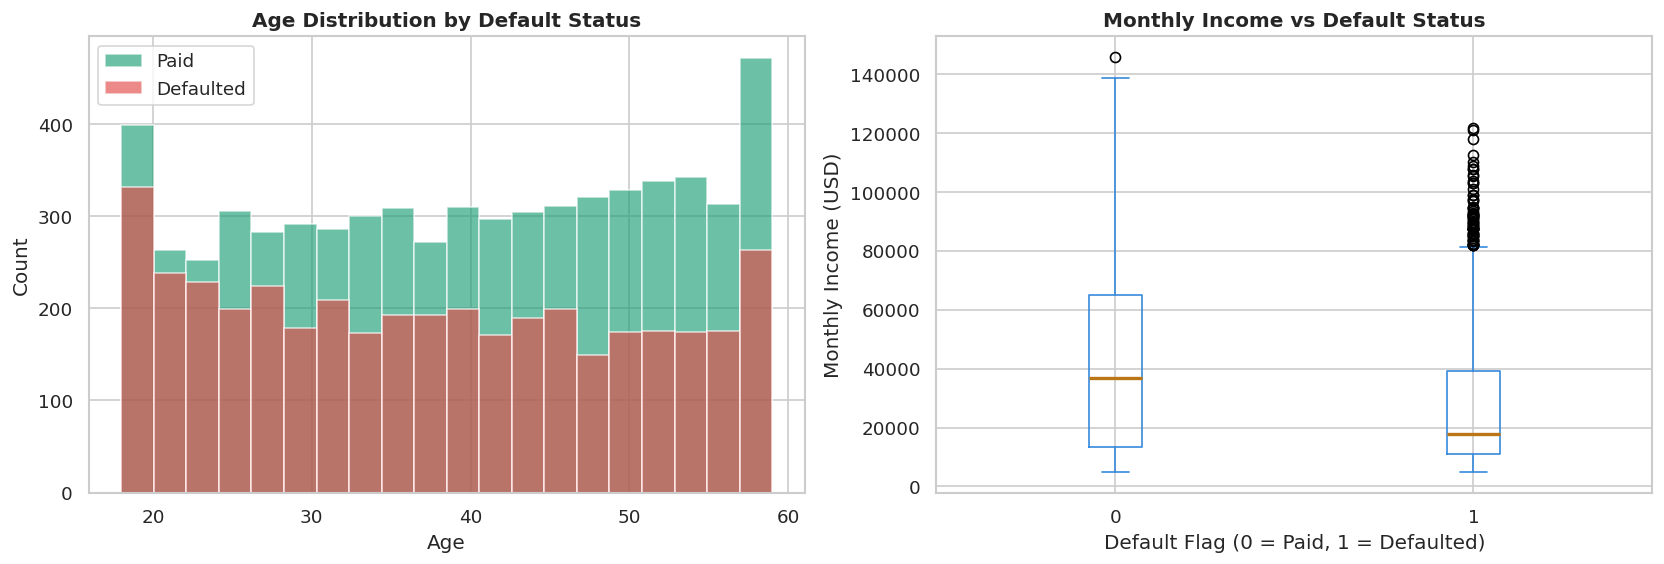

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Age distribution by default
for flag, label, color in [(0, 'Paid', COLORS['paid']), (1, 'Defaulted', COLORS['default'])]:
    axes[0].hist(df[df['default_flag']==flag]['age'], bins=20, alpha=0.65,
                 label=label, color=color, edgecolor='white')
axes[0].set_title('Age Distribution by Default Status', fontweight='bold')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')
axes[0].legend()

# Monthly income by default
df.boxplot(column='monthly_income', by='default_flag', ax=axes[1],
           boxprops=dict(color=COLORS['main']),
           medianprops=dict(color=COLORS['accent'], linewidth=2),
           whiskerprops=dict(color=COLORS['main']),
           capprops=dict(color=COLORS['main']))
axes[1].set_title('Monthly Income vs Default Status', fontweight='bold')
axes[1].set_xlabel('Default Flag (0 = Paid, 1 = Defaulted)')
axes[1].set_ylabel('Monthly Income (USD)')
plt.suptitle('')

plt.tight_layout()
plt.show()

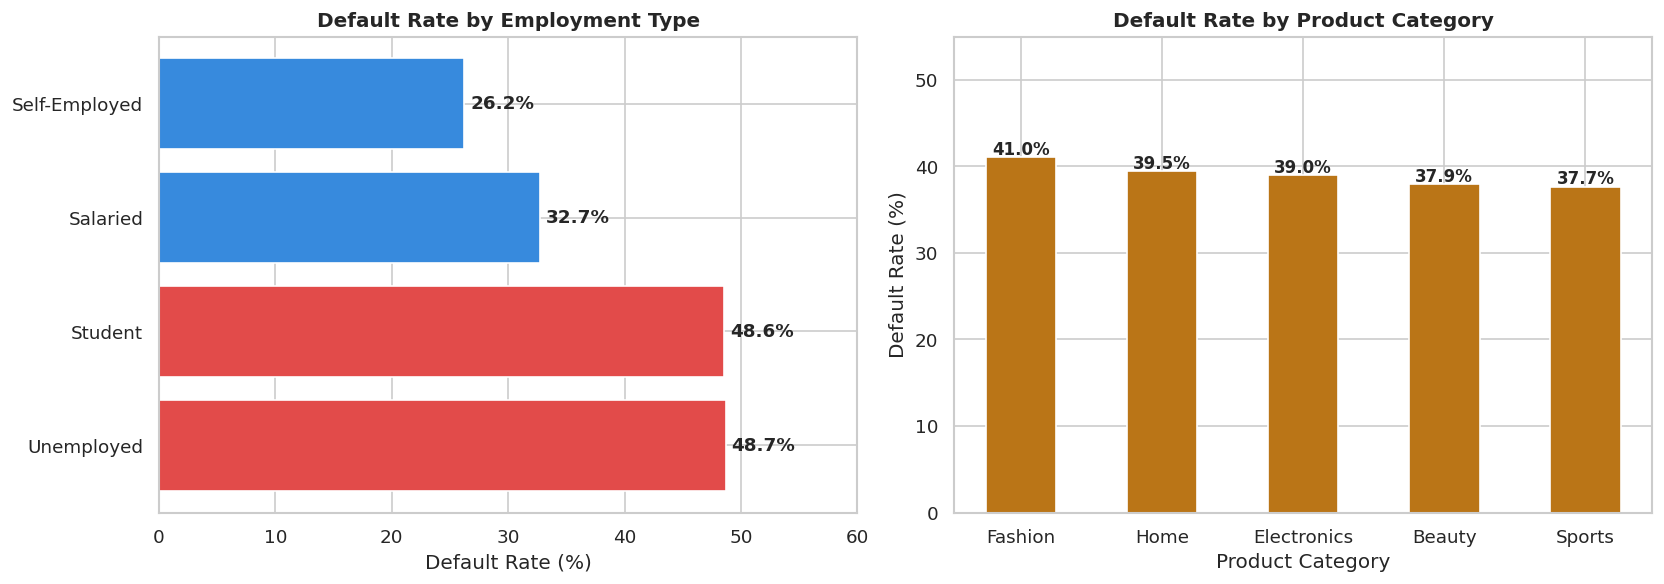

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by employment type
emp_default = df.groupby('employment_type')['default_flag'].mean().sort_values(ascending=False) * 100
bars = axes[0].barh(emp_default.index, emp_default.values,
                    color=[COLORS['default'] if v > 40 else COLORS['main'] for v in emp_default.values],
                    edgecolor='white')
for bar, val in zip(bars, emp_default.values, strict=False):
    axes[0].text(val + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.1f}%', va='center', fontweight='bold')
axes[0].set_title('Default Rate by Employment Type', fontweight='bold')
axes[0].set_xlabel('Default Rate (%)')
axes[0].set_xlim(0, 60)

# Default rate by product category
cat_default = df.groupby('product_category')['default_flag'].mean().sort_values(ascending=False) * 100
bars2 = axes[1].bar(cat_default.index, cat_default.values,
                    color=COLORS['accent'], edgecolor='white', width=0.5)
for bar, val in zip(bars2, cat_default.values, strict=False):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[1].set_title('Default Rate by Product Category', fontweight='bold')
axes[1].set_xlabel('Product Category')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.show()

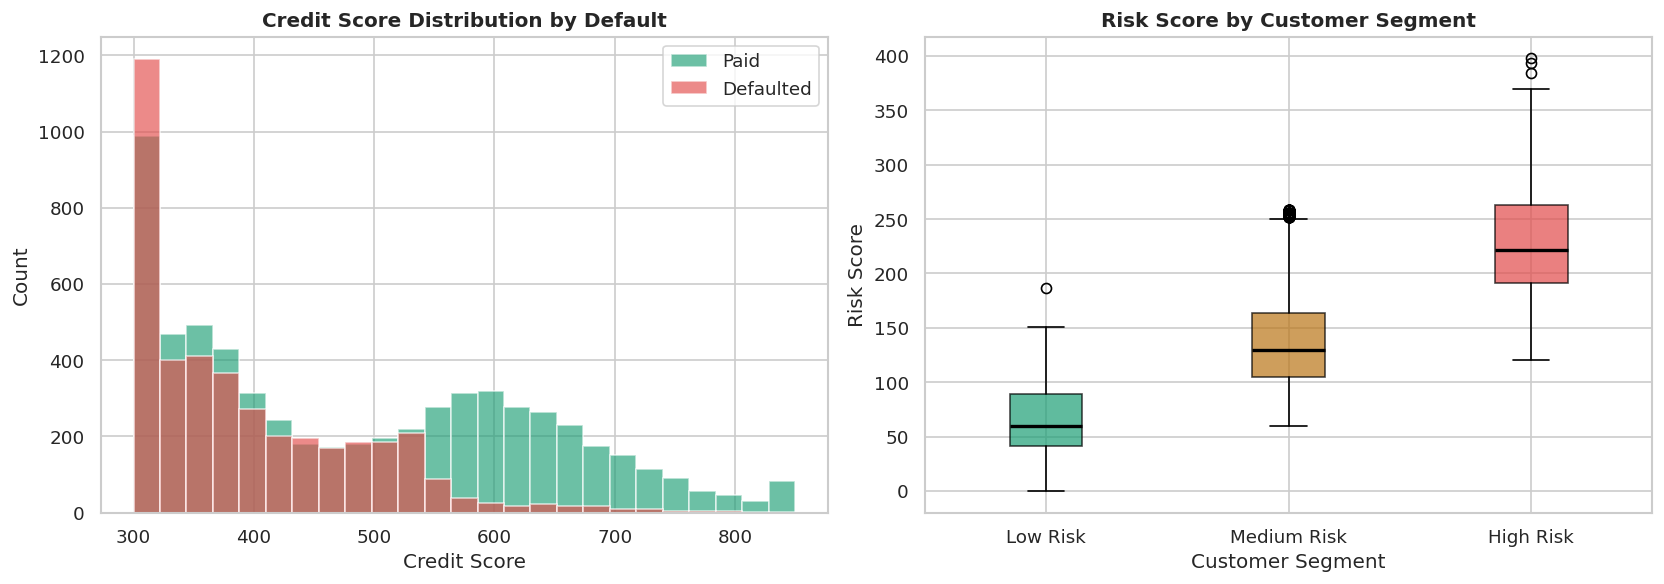

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Credit score vs default
for flag, label, color in [(0, 'Paid', COLORS['paid']), (1, 'Defaulted', COLORS['default'])]:
    axes[0].hist(df[df['default_flag']==flag]['credit_score'], bins=25,
                 alpha=0.65, label=label, color=color, edgecolor='white')
axes[0].set_title('Credit Score Distribution by Default', fontweight='bold')
axes[0].set_xlabel('Credit Score')
axes[0].set_ylabel('Count')
axes[0].legend()

# Risk score by customer segment
seg_order = ['Low Risk', 'Medium Risk', 'High Risk']
seg_colors = [COLORS['paid'], COLORS['accent'], COLORS['default']]
data_to_plot = [df[df['customer_segment']==seg]['risk_score'].values for seg in seg_order]
bp = axes[1].boxplot(data_to_plot, labels=seg_order, patch_artist=True)
for patch, color in zip(bp['boxes'], seg_colors, strict=False):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
for median in bp['medians']:
    median.set_color('black')
    median.set_linewidth(2)
axes[1].set_title('Risk Score by Customer Segment', fontweight='bold')
axes[1].set_xlabel('Customer Segment')
axes[1].set_ylabel('Risk Score')

plt.tight_layout()
plt.show()

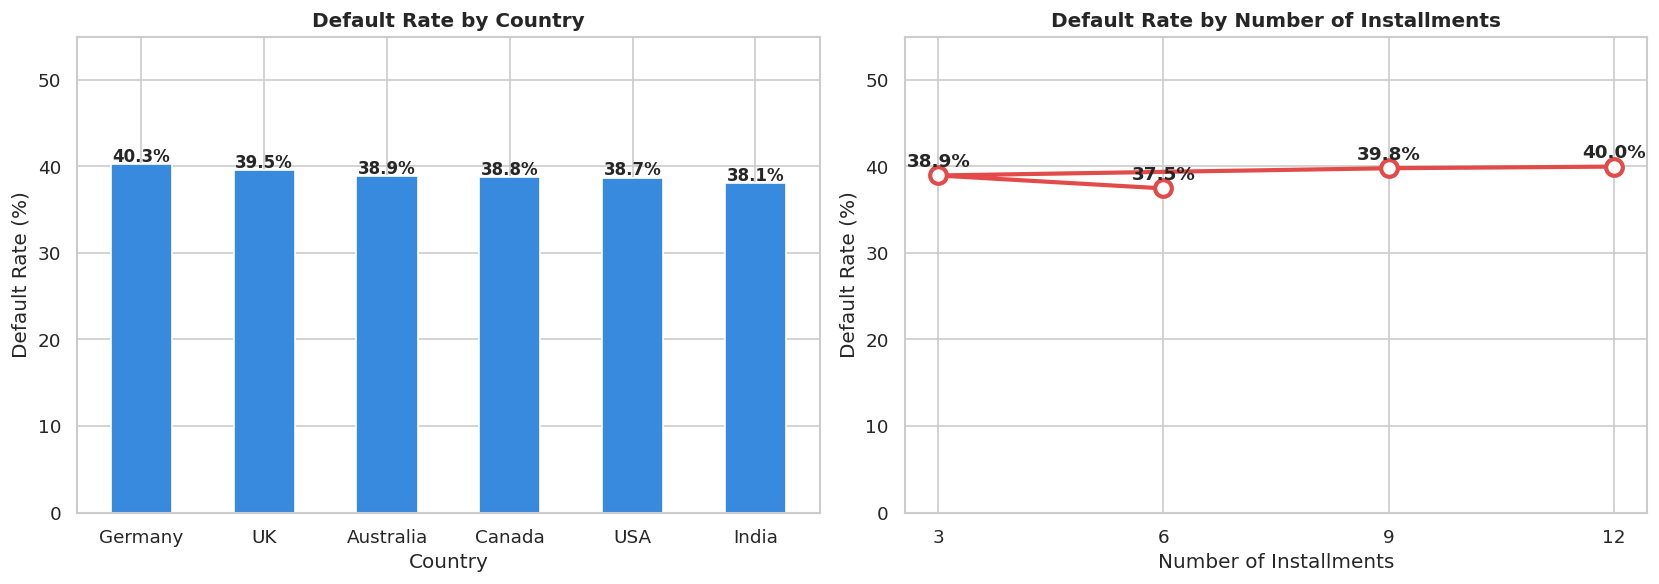

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Default rate by country
loc_default = df.groupby('location')['default_flag'].mean().sort_values(ascending=False) * 100
bars = axes[0].bar(loc_default.index, loc_default.values,
                   color=COLORS['main'], edgecolor='white', width=0.5)
for bar, val in zip(bars, loc_default.values, strict=False):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{val:.1f}%', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Default Rate by Country', fontweight='bold')
axes[0].set_xlabel('Country')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_ylim(0, 55)

# Default rate by installment plan
inst_default = df.groupby('bnpl_installments')['default_flag'].mean().sort_values() * 100
axes[1].plot(inst_default.index, inst_default.values,
             marker='o', color=COLORS['default'], linewidth=2.5,
             markersize=10, markerfacecolor='white', markeredgewidth=2.5)
for x, y in zip(inst_default.index, inst_default.values, strict=False):
    axes[1].text(x, y + 1, f'{y:.1f}%', ha='center', fontweight='bold')
axes[1].set_title('Default Rate by Number of Installments', fontweight='bold')
axes[1].set_xlabel('Number of Installments')
axes[1].set_ylabel('Default Rate (%)')
axes[1].set_xticks([3, 6, 9, 12])
axes[1].set_ylim(0, 55)

plt.tight_layout()
plt.show()

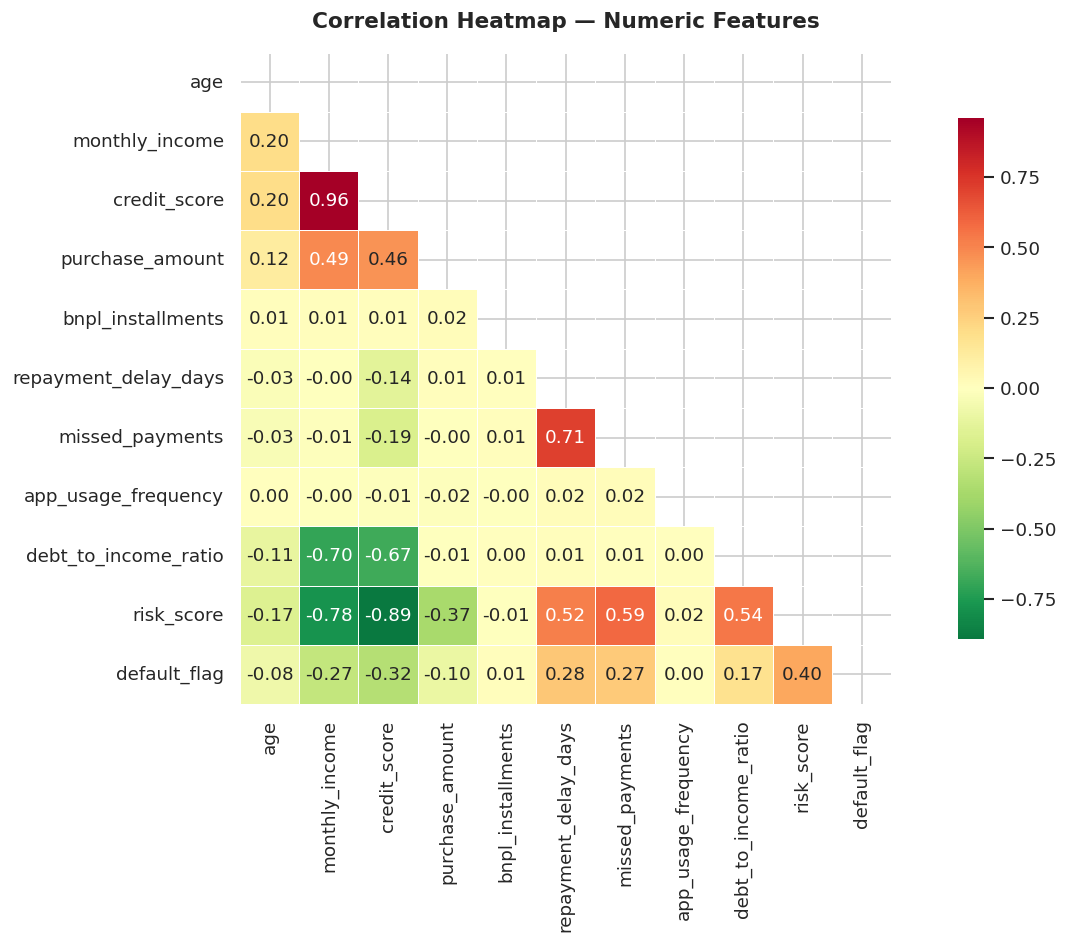


🔑 Top correlations with default_flag:
   risk_score                0.399
   credit_score              0.324
   repayment_delay_days      0.283
   monthly_income            0.274
   missed_payments           0.272
   debt_to_income_ratio      0.173
   purchase_amount           0.098
   age                       0.076
   bnpl_installments         0.012
   app_usage_frequency       0.004


In [8]:
# Correlation Heatmap — numeric features only
num_cols = ['age', 'monthly_income', 'credit_score', 'purchase_amount',
            'bnpl_installments', 'repayment_delay_days', 'missed_payments',
            'app_usage_frequency', 'debt_to_income_ratio', 'risk_score', 'default_flag']

fig, ax = plt.subplots(figsize=(12, 8))
corr = df[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8}, ax=ax)
ax.set_title('Correlation Heatmap — Numeric Features', fontweight='bold', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

print('\n🔑 Top correlations with default_flag:')
top_corr = corr['default_flag'].drop('default_flag').abs().sort_values(ascending=False)
for feat, val in top_corr.items():
    print(f'   {feat:<25} {val:.3f}')

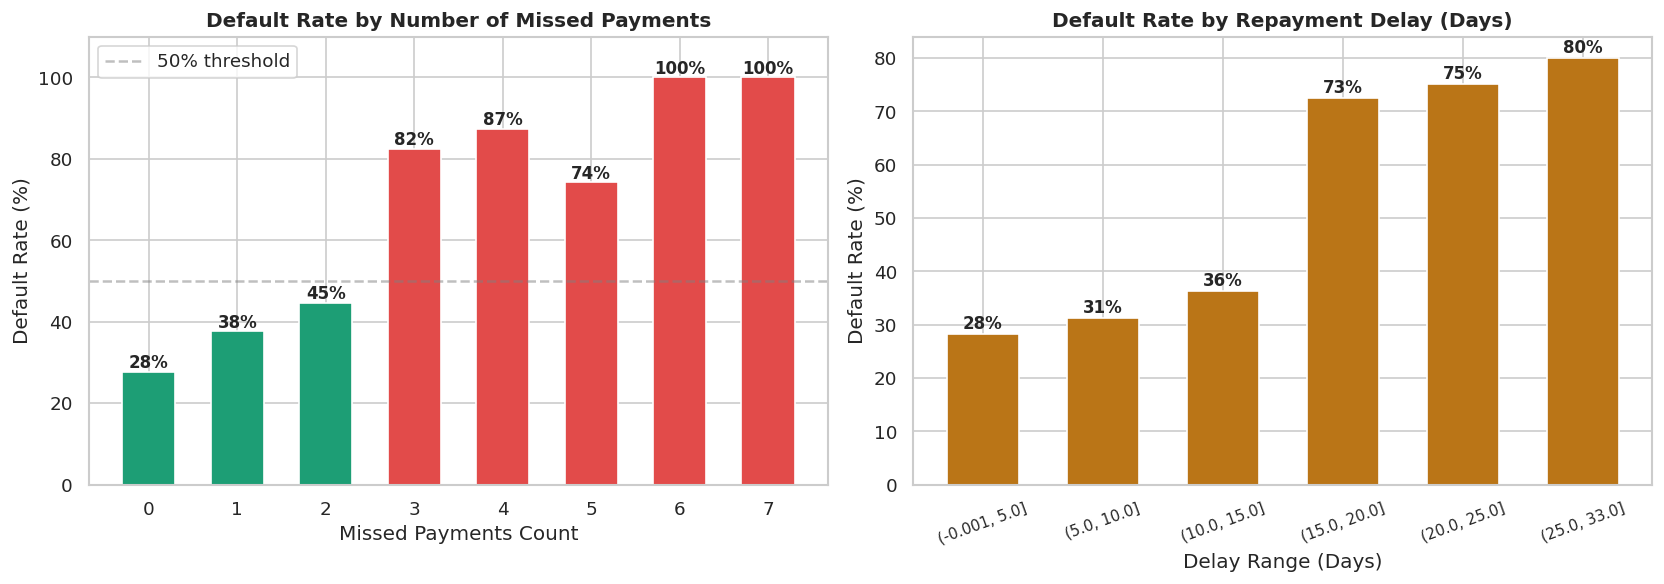

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Missed payments vs default rate
mp_default = df.groupby('missed_payments')['default_flag'].mean() * 100
axes[0].bar(mp_default.index, mp_default.values,
            color=[COLORS['paid'] if v < 50 else COLORS['default'] for v in mp_default.values],
            edgecolor='white', width=0.6)
for x, v in zip(mp_default.index, mp_default.values, strict=False):
    axes[0].text(x, v + 1, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].set_title('Default Rate by Number of Missed Payments', fontweight='bold')
axes[0].set_xlabel('Missed Payments Count')
axes[0].set_ylabel('Default Rate (%)')
axes[0].set_ylim(0, 110)
axes[0].axhline(50, color='gray', linestyle='--', alpha=0.5, label='50% threshold')
axes[0].legend()

# Repayment delay vs default
delay_bins = pd.cut(df['repayment_delay_days'], bins=[0,5,10,15,20,25,33], include_lowest=True)
delay_default = df.groupby(delay_bins, observed=True)['default_flag'].mean() * 100
axes[1].bar(range(len(delay_default)), delay_default.values,
            color=COLORS['accent'], edgecolor='white', width=0.6)
axes[1].set_xticks(range(len(delay_default)))
axes[1].set_xticklabels([str(i) for i in delay_default.index], rotation=20, fontsize=9)
axes[1].set_title('Default Rate by Repayment Delay (Days)', fontweight='bold')
axes[1].set_xlabel('Delay Range (Days)')
axes[1].set_ylabel('Default Rate (%)')
for i, v in enumerate(delay_default.values):
    axes[1].text(i, v + 1, f'{v:.0f}%', ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.show()

### 💡 EDA Summary — What We Learned

| Finding | Insight |
|---|---|
| **Unemployed users** default most | Makes sense — no stable income |
| **More missed payments = more defaults** | Strongest single predictor |
| **Higher credit score = fewer defaults** | Standard credit behaviour |
| **12 installment plans** have higher default | Longer commitment = harder to maintain |
| **Risk score** separates segments cleanly | Good engineered feature |
| **Country differences are small** | Location is a weak predictor |

---
## **⚙️ Step 4 — Feature Engineering**
We create **new features** from existing columns to help the model learn better patterns.

> 💡 Raw data is rarely enough. Feature engineering is where domain knowledge meets ML.

In [10]:
df_model = df.copy()

# ── New Features ───────────────────────────────────────────

# 1. Payment stress score — combines delay and missed payments
df_model['payment_stress'] = df_model['repayment_delay_days'] * df_model['missed_payments']

# 2. Income to purchase ratio — how affordable is the purchase?
df_model['income_to_purchase_ratio'] = df_model['monthly_income'] / (df_model['purchase_amount'] + 1)

# 3. Age group — young users may behave differently
df_model['age_group'] = pd.cut(df_model['age'],
                               bins=[17, 25, 35, 45, 60],
                               labels=['18-25', '26-35', '36-45', '46-59'])

# 4. Transaction month — any seasonal patterns?
df_model['txn_month'] = df_model['transaction_date'].dt.month

# 5. High risk flag — if risk_score > 250
df_model['is_high_risk'] = (df_model['risk_score'] > 250).astype(int)

print('✅ New features created:')
new_feats = ['payment_stress', 'income_to_purchase_ratio', 'age_group', 'txn_month', 'is_high_risk']
print(df_model[new_feats].head())

# ── Encode Categorical Columns ─────────────────────────────
cat_cols = ['employment_type', 'product_category', 'location', 'customer_segment', 'age_group']
le = LabelEncoder()
for col in cat_cols:
    df_model[col] = le.fit_transform(df_model[col].astype(str))

print('\n✅ Categorical columns encoded')

✅ New features created:
   payment_stress  income_to_purchase_ratio age_group  txn_month  is_high_risk
0              13                 13.703159     46-59          6             0
1              13                  6.747019     18-25         10             1
2              38                  8.314789     18-25          4             0
3              90                  3.537043     18-25          6             1
4               0                  8.567387     36-45         10             0

✅ Categorical columns encoded


---
## **🤖 Step 5 — Build XGBoost Model**
XGBoost (Extreme Gradient Boosting) is one of the **most powerful algorithms for tabular data**. It builds many small decision trees one after another, each correcting the mistakes of the previous one.

> 💡 XGBoost wins most Kaggle tabular competitions. It handles missing values, is fast, and works great out of the box.

In [11]:
# Define features and target
drop_cols = ['user_id', 'transaction_date', 'default_flag']
X = df_model.drop(columns=drop_cols)
y = df_model['default_flag']

# Handle class imbalance
scale_pos = (y == 0).sum() / (y == 1).sum()
print(f'scale_pos_weight = {scale_pos:.2f} (accounts for class imbalance)')

# Train / Test split — stratified to preserve class ratio
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f'\nTrain size: {X_train.shape[0]:,} rows')
print(f'Test size : {X_test.shape[0]:,} rows')

# Build XGBoost model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos,
    use_label_encoder=False,
    eval_metric='logloss',
    random_state=42
)

model.fit(X_train, y_train,
          eval_set=[(X_test, y_test)],
          verbose=False)

print('\n✅ Model trained successfully!')

scale_pos_weight = 1.56 (accounts for class imbalance)

Train size: 8,276 rows
Test size : 2,069 rows

✅ Model trained successfully!


---
## **📊 Step 6 — Evaluate & Interpret Results**
A model is useless if we can't understand how well it works. We use:
- **Confusion Matrix** — shows correct vs wrong predictions
- **Classification Report** — precision, recall, F1
- **ROC-AUC Curve** — overall model quality (closer to 1.0 = better)
- **Feature Importance** — which features the model used most

In [12]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_prob)

print('=' * 50)
print(f'  ROC-AUC Score : {auc:.4f}')
print('=' * 50)
print()
print(classification_report(y_test, y_pred, target_names=['Paid', 'Defaulted']))

  ROC-AUC Score : 0.7732

              precision    recall  f1-score   support

        Paid       0.76      0.70      0.73      1261
   Defaulted       0.58      0.66      0.62       808

    accuracy                           0.68      2069
   macro avg       0.67      0.68      0.67      2069
weighted avg       0.69      0.68      0.69      2069



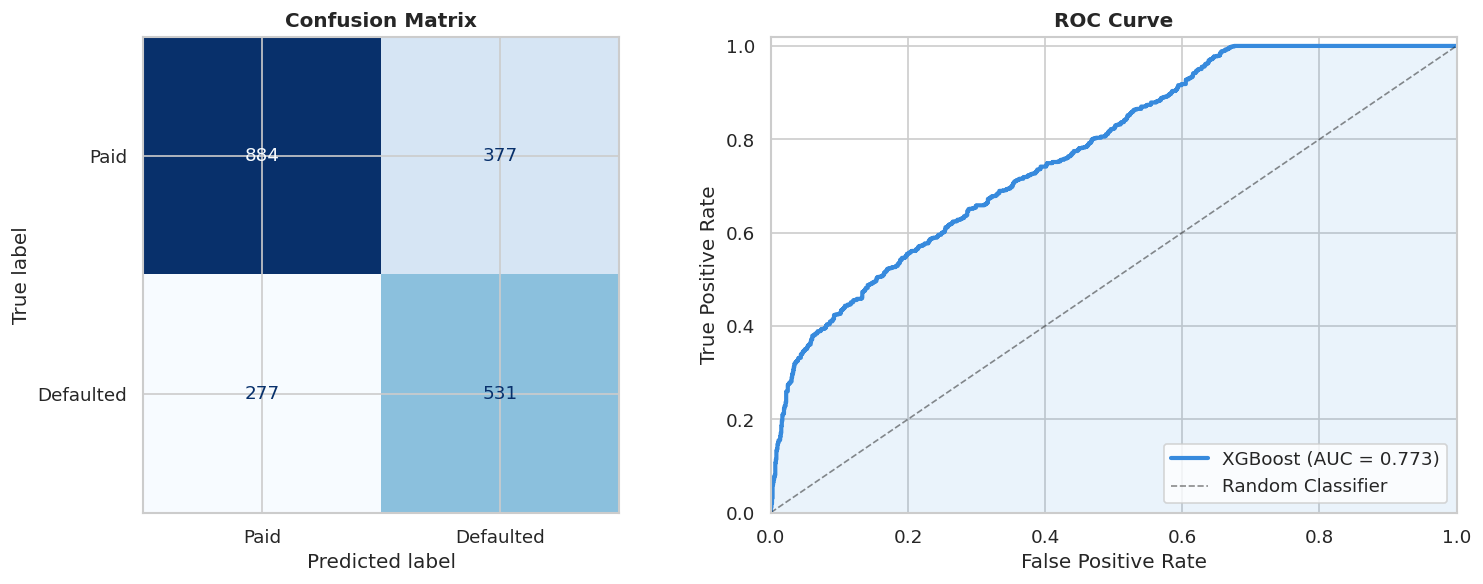

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Paid', 'Defaulted'])
disp.plot(ax=axes[0], colorbar=False,
          cmap='Blues')
axes[0].set_title('Confusion Matrix', fontweight='bold', fontsize=12)

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_prob)
axes[1].plot(fpr, tpr, color=COLORS['main'], linewidth=2.5,
             label=f'XGBoost (AUC = {auc:.3f})')
axes[1].plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random Classifier')
axes[1].fill_between(fpr, tpr, alpha=0.1, color=COLORS['main'])
axes[1].set_title('ROC Curve', fontweight='bold', fontsize=12)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(loc='lower right')
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

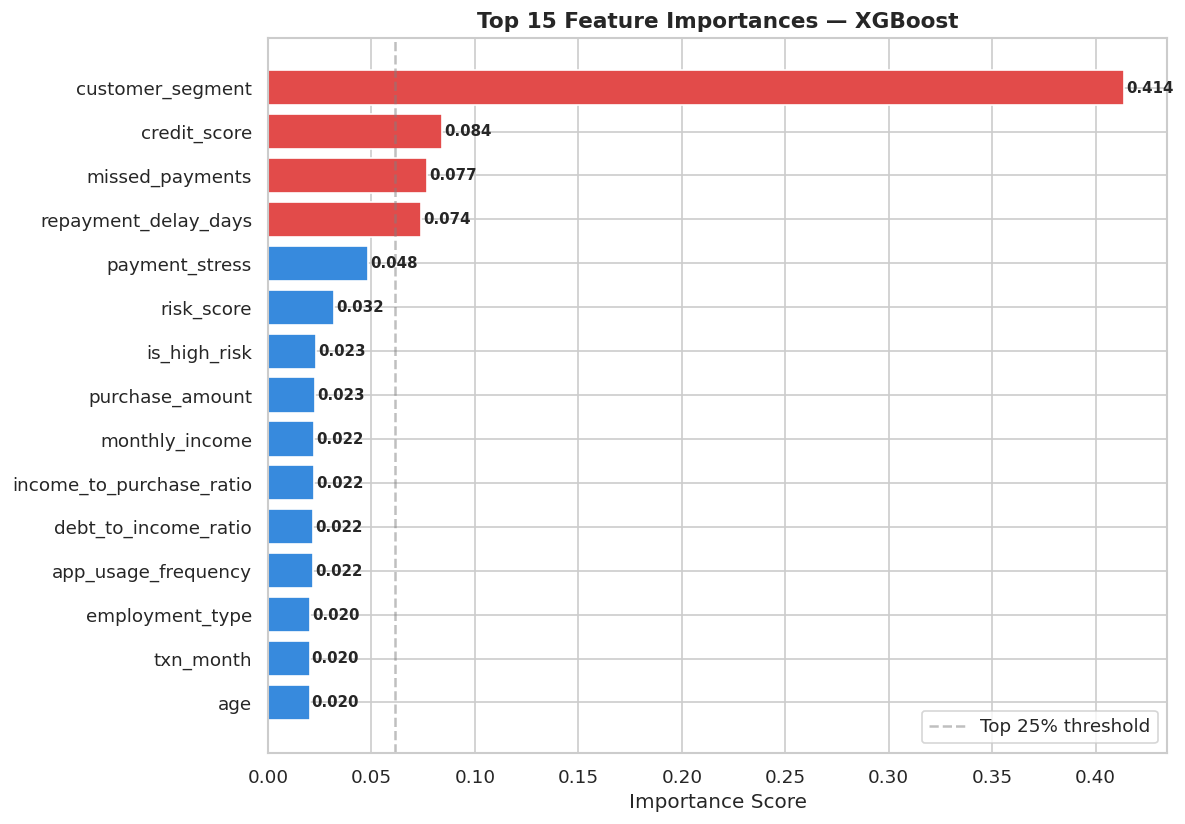


🏆 Top 5 most important features:
   customer_segment               0.4138
   credit_score                   0.0840
   missed_payments                0.0770
   repayment_delay_days           0.0740
   payment_stress                 0.0483


In [14]:
# Feature Importance
importance = pd.Series(model.feature_importances_, index=X.columns)
importance = importance.sort_values(ascending=True).tail(15)

fig, ax = plt.subplots(figsize=(10, 7))
colors_bar = [COLORS['default'] if v > importance.quantile(0.75) else COLORS['main']
              for v in importance.values]
bars = ax.barh(importance.index, importance.values, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, importance.values, strict=False):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9, fontweight='bold')
ax.set_title('Top 15 Feature Importances — XGBoost', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
ax.axvline(importance.quantile(0.75), color='gray', linestyle='--',
           alpha=0.5, label='Top 25% threshold')
ax.legend()
plt.tight_layout()
plt.show()

print('\n🏆 Top 5 most important features:')
for feat, val in importance.sort_values(ascending=False).head(5).items():
    print(f'   {feat:<30} {val:.4f}')

In [15]:
# Cross-Validation — to make sure our results are stable
print('Running 5-Fold Cross Validation...')
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc', n_jobs=-1)

print('\n✅ Cross-Validation ROC-AUC Scores:')
for i, score in enumerate(cv_scores, 1):
    print(f'   Fold {i}: {score:.4f}')
print(f'\n   Mean  : {cv_scores.mean():.4f}')
print(f'   Std   : {cv_scores.std():.4f}')
print('\n💡 Low std means our model is stable and not overfitting.')

Running 5-Fold Cross Validation...


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:20:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:20:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:20:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [05:20:34] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:


✅ Cross-Validation ROC-AUC Scores:
   Fold 1: 0.7705
   Fold 2: 0.7675
   Fold 3: 0.7733
   Fold 4: 0.7610
   Fold 5: 0.7692

   Mean  : 0.7683
   Std   : 0.0041

💡 Low std means our model is stable and not overfitting.


---
## **🏁 Key Takeaways**

### **What We Built**
An **end-to-end BNPL default prediction pipeline** — from raw data to a trained XGBoost model.

### **What We Found**

| # | Finding |
|---|---|
| 1 | `missed_payments` and `risk_score` are the strongest predictors of default |
| 2 | Unemployed users have the highest default rate |
| 3 | Longer installment plans (12 months) correlate with more defaults |
| 4 | Credit score helps — but it's not the only signal |
| 5 | Our engineered feature `payment_stress` added predictive value |

### **What You Can Try Next**

- 🔬 Try **LightGBM or CatBoost** and compare with XGBoost
- 📉 Apply **SMOTE** to handle class imbalance more aggressively
- 🔧 Use **Optuna** or **GridSearchCV** for hyperparameter tuning
- 🧠 Add **SHAP values** for deeper model explainability
- 📅 Build a **time-based train/test split** using `transaction_date`

---

> ⭐ **If this notebook helped you, please upvote the dataset and the notebook — it motivates me to create more!**

